In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller

## 
import FEATURE_IMPORTANCE as fi
import FFD as fd
import TB_LABELING as tb
import CUSUM_FILTER as cf

In [3]:
df = pd.read_csv('/workspaces/XFUND/AEX.csv')
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)
display(df)
df.dropna(inplace=True)
missing_values = df.isna().sum()
print("Number of missing values in 'Close' column:", missing_values)

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
1992-10-12,126.382904,127.181557,126.056175,126.945595,126.945595,0.0
1992-10-13,126.773155,127.004585,126.491806,126.850296,126.850296,0.0
1992-10-14,126.056175,126.555336,126.001724,126.487274,126.487274,0.0
1992-10-15,126.097015,126.568954,125.688614,125.824753,125.824753,0.0
1992-10-16,126.264915,126.478195,124.858192,125.230293,125.230293,0.0
...,...,...,...,...,...,...
2023-10-13,738.820007,743.000000,733.080017,733.900024,733.900024,54300.0
2023-10-16,736.809998,737.559998,731.500000,735.390015,735.390015,44000.0
2023-10-17,733.450012,738.429993,730.500000,736.770020,736.770020,43800.0


Number of missing values in 'Close' column: Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64


/workspaces/XFUND/FFD.py:55: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  seriesF, df_ = series[[name]].fillna(method='ffill').dropna(), pd.Series()
/workspaces/XFUND/FFD.py:55: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  seriesF, df_ = series[[name]].fillna(method='ffill').dropna(), pd.Series()
/workspaces/XFUND/FFD.py:55: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  seriesF, df_ = series[[name]].fillna(method='ffill').dropna(), pd.Series()
/workspaces/XFUND/FFD.py:55: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  seriesF, df_ = series[[name]].fillna(method='ffill').dropna(), pd.Series()
/workspaces/XFUND/FFD.py:55: Fut

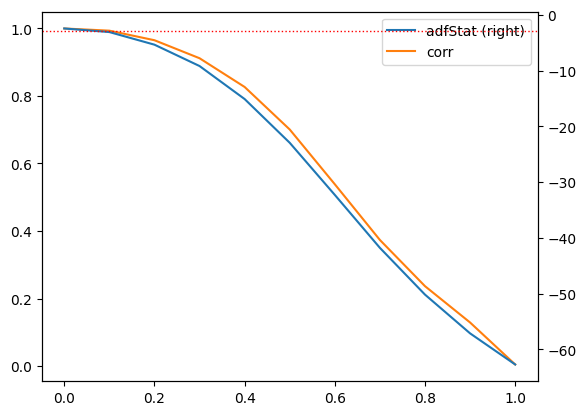

,adfStat,pVal,lags,nObs,95% conf,corr
0.0,-2.464199,1.244299e-01,1.0,7915.0,-2.861905,1.000000
0.1,-3.107803,2.598111e-02,1.0,7564.0,-2.861922,0.993504
0.2,-5.369022,3.933398e-06,1.0,7569.0,-2.861922,0.965185
0.3,-9.199144,2.024195e-15,1.0,7646.0,-2.861918,0.911842
0.4,-15.119096,7.504801e-28,1.0,7722.0,-2.861914,0.826710
0.5,-22.963524,0.000000e+00,1.0,7777.0,-2.861912,0.700740
0.6,-32.308530,0.000000e+00,1.0,7818.0,-2.861910,0.538498
0.7,-41.805458,0.000000e+00,1.0,7848.0,-2.861908,0.373432
0.8,-50.189176,0.000000e+00,1.0,7870.0,-2.861907,0.236572
0.9,-57.139029,0.000000e+00,1.0,7888.0,-2.861906,0.128932


In [4]:
fd.plotMinFFD(df,'Close')

In [5]:
df_pre_stationary = df.drop(['Volume'], axis=1)
df_post_stat = fd.fracDiff_FFD(df_pre_stationary,0.2,thres=1e-4)
display(df_post_stat)

/workspaces/XFUND/FFD.py:55: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  seriesF, df_ = series[[name]].fillna(method='ffill').dropna(), pd.Series()
/workspaces/XFUND/FFD.py:55: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  seriesF, df_ = series[[name]].fillna(method='ffill').dropna(), pd.Series()
/workspaces/XFUND/FFD.py:55: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  seriesF, df_ = series[[name]].fillna(method='ffill').dropna(), pd.Series()
/workspaces/XFUND/FFD.py:55: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  seriesF, df_ = series[[name]].fillna(method='ffill').dropna(), pd.Series()
/workspaces/XFUND/FFD.py:55: Fut

,Open,High,Low,Close,Adj Close
1994-09-23,44.586147,45.866775,45.026233,46.236605,46.236605
1994-09-26,46.242582,46.094197,45.113438,44.678967,44.678967
1994-09-27,44.636195,44.442125,44.888166,45.051191,45.051191
1994-09-28,45.640273,46.657065,46.256955,47.189309,47.189309
1994-09-29,46.568113,46.101317,46.809449,46.327844,46.327844
...,...,...,...,...,...
2023-10-13,184.761244,185.835322,181.004671,179.537815,179.537815
2023-10-16,182.623735,180.191607,180.096494,181.956898,181.956898
2023-10-17,179.435275,181.924421,179.494617,183.263945,183.263945
2023-10-18,179.272299,181.360501,177.515126,175.761362,175.761362


In [6]:
print(len(df))
print(len(df_post_stat))

result = adfuller(df_post_stat['Close'])
p_value = result[1]

if p_value <= 0.05:
    print("The time series is likely stationary.")
else:
    print("The time series is likely non-stationary.")

7917
7421
The time series is likely stationary.


In [8]:
# Feature Engineering

feature_importance = fi.featImportance(df_post_stat)

TypeError: featImportance() missing 1 required positional argument: 'cont'